# 11.1HD – Machine Learning Research
### Name: Chehul Chinnappa T.N
### Student Id: 225269854

### Selected Research Paper
Bhagat, M., Sharma, A. and Agarwal, P., "An efficient stacking-based ensemble technique for early heart attack prediction."

## Research Objective

The main objective of this study is to reproduce the ML experiment in the research paper “An efficient stacking-based ensemble technique for early heart attack prediction.” and then evalutate if can reproduce the reported performance.

In the original study, the paper compared 6 machine learning classifiers for heart diseases prediction and proposed a stacking-based ensemble to improve the predictive performance.

This research will be divided into parts, with the first part focusing on reproducing the original approach, and the second part will be to identify any limitations in the published methodology and to develop an improved machine learning solution.

## Part 1

### 1.1 Loading and Inspecting the dataset
In this section, we will load the dataset, and then inspect it to know the dataset's shape, column names, if it has any missing values, or any duplicates. We will also look at the target distribution.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

RANDOM_STATE = 225269854

In [2]:
# Loading the dataset
heart_data = pd.read_csv("../data/heart.csv")

print("Dataset shape:", heart_data.shape)
heart_data.head()

Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Checking the columns
print("Dataset columns:")
print(heart_data.columns.tolist())

Dataset columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [4]:
# Checking the structure
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
# Checking for missing values
missing_values = heart_data.isnull().sum()

print("Missing Values:")
print(missing_values)
print("Total missing values:", heart_data.isnull().sum().sum())

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Total missing values: 0


In [6]:
# Checking for duplicates
duplicate_observation = heart_data.duplicated().sum()
print("Number of the duplicate rows:", duplicate_observation)

Number of the duplicate rows: 723


In [7]:
# Looking at the target distribution
target_count = heart_data["target"].value_counts().sort_index()
target_percent = heart_data["target"].value_counts(normalize = True).sort_index()*100

target_summary = pd.DataFrame({
    "Count" : target_count,
    "Percentage" : target_percent
})

target_summary

,Count,Percentage
target,,
0,499,48.682927
1,526,51.317073


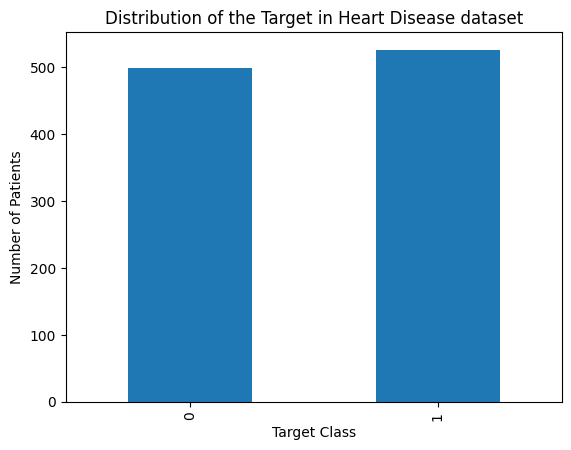

In [8]:
target_count.plot(kind="bar")

plt.title("Distribution of the Target in Heart Disease dataset")
plt.xlabel("Target Class")
plt.ylabel("Number of Patients")

plt.show()

In [9]:
# Checking for unique values
for column in heart_data.columns:
    print(f"{column}: {sorted(heart_data[column].unique())}")

age: [np.int64(29), np.int64(34), np.int64(35), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(74), np.int64(76), np.int64(77)]
sex: [np.int64(0), np.int64(1)]
cp: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
trestbps: [np.int64(94), np.int64(100), np.int64(101), np.int64(102), np.int64(104), np.int64(105), np.int64(106), np.int64(108), np.int64(110), np.int64(112), np.int64(114), np.int64(115), np.int64(117), np.int64(118), np.int64(120), np.int64(122), np.int64(123), np.int64(124), np.int64(125), np.int64(126), np.int64(128), np.int

The dataset has 1,025 observations and 14 variables, and it matches the dimensions mentioned in the research paper. The 13 predictor variables and the target variable were present as expected.

The imputation process mentioned in the paper is not required as no missing values were found. The target variable is almost balanced, with 51.32% heart-disease cases and 48.68% non-heart-disease cases.

However, the most important finding is that the dataset has 723 duplicate rows, which leaves 302 unique observations. The duplicates will be initially be retained to support  the reproduction of the published experiment, but, it will be considered for critical analysis in the later stages.

### 1.2 Reproducing the Paper results

The original research paper handles missing-value , normalisation and categorical encoding in preprocessing, before separating the data into training and testing sets. However, the implementation details like the train-test ratio, and random seed and classifier hyperparameters are not mentioned.

To reproduce the results, the following assumptions were made:

1. The original 1,025 observations are retained, including the duplicate records, to have a consistent dataset with the one used by the paper.

2. As there were no missing values, no imputation is applied

3. The existing dataset is already numerically encoded, so the existing numerical coding of categorical attributes is retained.

4. An 80:20 stratified train-test split is used with random_state as 225269854

5. Standard scaler is used only on training set, to avoid data leakage

6. The default classifier parametes are used initially as the paper doesnot specify the parameter.

7. Five-fold stratified cross-validation is used for the stacking ensemble.

#### Preparing the dataset

In [10]:
# Seperating the predictor variables and target
X = heart_data.drop("target", axis=1)
target = heart_data["target"]

print("Feature shape:", X.shape)
print("Target shape:", target.shape)

Feature shape: (1025, 13)
Target shape: (1025,)


In [11]:
# Training and Testing split
from sklearn.model_selection import train_test_split

X_train, X_test, target_train, target_test = train_test_split(
    X,
    target,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify= target
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(target_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(target_test.value_counts(normalize=True))

Training set: (820, 13)
Testing set: (205, 13)

Training target distribution:
target
1    0.513415
0    0.486585
Name: proportion, dtype: float64

Testing target distribution:
target
1    0.512195
0    0.487805
Name: proportion, dtype: float64


In [12]:
# Scaling the training data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape after scaling:",X_train_scaled.shape)
print("Testing shape after scaling:",X_test_scaled.shape)

Training shape after scaling: (820, 13)
Testing shape after scaling: (205, 13)


The dataset was split using stratified 80:20 train-test split, and then the Standardisation was fit only on the training data, and then applied to the test dataset. This helps in maintaing the target class distribution, and also prevent any data leak from the test set.

#### Reproducing the six classifiers

In [13]:
# the paper uses Logistic Regression, Decision Tree, Random Forest, Extreme Gradient Boost, Naive Bayes and KNN
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score,
roc_auc_score, confusion_matrix, matthews_corrcoef)

In [14]:
# Creating a function to evaluate the models
def model_evaluator(name, model, X_test, target_test):
    target_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        target_prob = model.predict_proba(X_test)[:,1]
    elif hasattr(model, "decision_function"):
        target_prob = model.decision_function(X_test)
    else:
        target_prob = target_pred

    tn, fp, fn, tp = confusion_matrix(target_test, target_pred).ravel()

    specificity = tn / (tn+fp)

    return {
        "Model": name,
        "Accuracy": accuracy_score(target_test, target_pred),
        "Precision": precision_score(target_test, target_pred),
        "Recall": recall_score(target_test, target_pred),
        "F1": f1_score(target_test, target_pred),
        "Specificity": float(specificity),
        "MCC": matthews_corrcoef(target_test, target_pred),
        "AUC": roc_auc_score(target_test, target_prob)
    }

In [15]:
# Evaluating each models
# Logistic Regression
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression(
    max_iter = 1000,
    random_state = RANDOM_STATE
)

logistic_regression.fit(X_train_scaled, target_train)
logistic_regression_result = model_evaluator("Logistic Regression",
                                             logistic_regression,
                                             X_test_scaled,
                                             target_test
                                            )

logistic_regression_result

{'Model': 'Logistic Regression',
 'Accuracy': 0.8,
 'Precision': 0.7909090909090909,
 'Recall': 0.8285714285714286,
 'F1': 0.8093023255813954,
 'Specificity': 0.77,
 'MCC': 0.600001708815065,
 'AUC': 0.8927619047619048}

In [16]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state = RANDOM_STATE
)

decision_tree.fit(X_train, target_train)
decision_tree_result = model_evaluator("Decision Tree",
                                             decision_tree,
                                             X_test,
                                             target_test
                                            )

decision_tree_result

{'Model': 'Decision Tree',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1': 1.0,
 'Specificity': 1.0,
 'MCC': 1.0,
 'AUC': 1.0}

In [17]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    random_state = RANDOM_STATE
)

random_forest.fit(X_train, target_train)
random_forest_result = model_evaluator("Random Forest",
                                             random_forest,
                                             X_test,
                                             target_test
                                            )

random_forest_result

{'Model': 'Random Forest',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1': 1.0,
 'Specificity': 1.0,
 'MCC': 1.0,
 'AUC': 1.0}

In [18]:
# Extreme Gradient Boost 
from xgboost import XGBClassifier

extreme_gradient_boost = XGBClassifier(
    random_state = RANDOM_STATE,
    eval_metric="logloss"
)

extreme_gradient_boost.fit(X_train, target_train)
extreme_gradient_boost_result = model_evaluator("XGBoost",
                                                extreme_gradient_boost,
                                                X_test,
                                                target_test)

extreme_gradient_boost_result

{'Model': 'XGBoost',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1': 1.0,
 'Specificity': 1.0,
 'MCC': 1.0,
 'AUC': 1.0}

In [19]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()

naive_bayes.fit(X_train_scaled, target_train)
naive_bayes_result = model_evaluator("Naive Bayes",
                                     naive_bayes,
                                     X_test_scaled,
                                     target_test)

naive_bayes_result

{'Model': 'Naive Bayes',
 'Accuracy': 0.7951219512195122,
 'Precision': 0.7837837837837838,
 'Recall': 0.8285714285714286,
 'F1': 0.8055555555555556,
 'Specificity': 0.76,
 'MCC': 0.5904299908875641,
 'AUC': 0.8726666666666667}

In [20]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, target_train)
knn_result = model_evaluator("KNN",
                             knn,
                             X_test_scaled,
                             target_test)

knn_result

{'Model': 'KNN',
 'Accuracy': 0.8,
 'Precision': 0.826530612244898,
 'Recall': 0.7714285714285715,
 'F1': 0.7980295566502463,
 'Specificity': 0.83,
 'MCC': 0.6018299252079278,
 'AUC': 0.923}

In [21]:
model_comparison = pd.DataFrame([
    logistic_regression_result,
    decision_tree_result,
    random_forest_result,
    extreme_gradient_boost_result,
    naive_bayes_result,
    knn_result
])

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,Specificity,MCC,AUC
0,Logistic Regression,0.8000,0.7909,0.8286,0.8093,0.77,0.6000,0.8928
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000
3,XGBoost,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000
4,Naive Bayes,0.7951,0.7838,0.8286,0.8056,0.76,0.5904,0.8727
5,KNN,0.8000,0.8265,0.7714,0.7980,0.83,0.6018,0.9230


#### Reproducing the stacking ensemble

In [22]:
# Pipelines for models that need scaling
from sklearn.pipeline import Pipeline

logistic_regression_stack = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter = 1000, random_state =RANDOM_STATE))
])

knn_stack = Pipeline([
    ("scaler", StandardScaler()),
    ("model",KNeighborsClassifier())
])

naive_bayes_stack = Pipeline([
    ("scaler", StandardScaler()),
    ("model",GaussianNB())
])

In [23]:
decision_tree_stack = DecisionTreeClassifier(random_state=RANDOM_STATE)

random_forest_stack = RandomForestClassifier(random_state=RANDOM_STATE)

extreme_gradient_boost_stack = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

In [24]:
# The six base models:
estimators = [
    ("logistic_regrssion",logistic_regression_stack),
    ("decision_tree", decision_tree_stack),
    ("random_forest",random_forest_stack),
    ("extreme_gradient_boost",extreme_gradient_boost_stack),
    ("naive_bayes", naive_bayes_stack),
    ("knn",knn_stack)
]

In [25]:
# Five-fold stacking
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold

stack_cv = StratifiedKFold( n_splits = 5,
                            shuffle = True,
                            random_state = RANDOM_STATE)

stacking_model = StackingClassifier( estimators = estimators,
                                     final_estimator = LogisticRegression(
                                         max_iter = 1000,
                                         random_state = RANDOM_STATE),
                                     cv = stack_cv,
                                     stack_method = "predict_proba"
                                   )
stacking_model.fit(X_train, target_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('logistic_regrssion', ...), ('decision_tree', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ate=225269854)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify th

In [26]:
stacking_result = model_evaluator("Stacking Ensemble",
                                  stacking_model,
                                  X_test,
                                  target_test
                                 )
stacking_result                               

{'Model': 'Stacking Ensemble',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1': 1.0,
 'Specificity': 1.0,
 'MCC': 1.0,
 'AUC': 1.0}

In [27]:
reproduced_results = pd.concat([
    model_comparison,
    pd.DataFrame([stacking_result])
], ignore_index = True)

reproduced_results.round(4)

,Model,Accuracy,Precision,Recall,F1,Specificity,MCC,AUC
0,Logistic Regression,0.8000,0.7909,0.8286,0.8093,0.77,0.6000,0.8928
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000
3,XGBoost,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000
4,Naive Bayes,0.7951,0.7838,0.8286,0.8056,0.76,0.5904,0.8727
5,KNN,0.8000,0.8265,0.7714,0.7980,0.83,0.6018,0.9230
6,Stacking Ensemble,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000


In [28]:
# Published result
published_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Naive Bayes",
        "KNN",
        "Stacking Ensemble"
    ],

    "Published Accuracy": [
        0.8439,
        0.9268,
        0.9268,
        0.9073,
        0.8439,
        0.8585,
        0.9853
    ],

    "Published F1": [
        0.8620,
        0.9289,
        0.9333,
        0.9132,
        0.8608,
        0.8687,
        0.9861
    ],

    "Published Recall": [
        0.9090,
        0.8909,
        0.9545,
        0.9090,
        0.9000,
        0.8727,
        0.9727
    ],

    "Published Precision": [
        0.8196,
        0.9702,
        0.9130,
        0.9174,
        0.8250,
        0.8648,
        1.0000
    ],

    "Published AUC": [
        0.9204,
        0.9702,
        0.9734,
        0.9830,
        0.9185,
        0.9304,
        0.9880
    ]
})

In [29]:
# Merging the published and reproduced table
comparison_table = published_results.merge(
    reproduced_results[
        ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
    ],on="Model")

comparison_table.round(4)

,Model,Published Accuracy,Published F1,Published Recall,Published Precision,Published AUC,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8439,0.8620,0.9090,0.8196,0.9204,0.8000,0.7909,0.8286,0.8093,0.8928
1,Decision Tree,0.9268,0.9289,0.8909,0.9702,0.9702,1.0000,1.0000,1.0000,1.0000,1.0000
2,Random Forest,0.9268,0.9333,0.9545,0.9130,0.9734,1.0000,1.0000,1.0000,1.0000,1.0000
3,XGBoost,0.9073,0.9132,0.9090,0.9174,0.9830,1.0000,1.0000,1.0000,1.0000,1.0000
4,Naive Bayes,0.8439,0.8608,0.9000,0.8250,0.9185,0.7951,0.7838,0.8286,0.8056,0.8727
5,KNN,0.8585,0.8687,0.8727,0.8648,0.9304,0.8000,0.8265,0.7714,0.7980,0.9230
6,Stacking Ensemble,0.9853,0.9861,0.9727,1.0000,0.9880,1.0000,1.0000,1.0000,1.0000,1.0000


In [30]:
# Finding the accuracy difference between published and reproduced
comparison_table["Accuracy Difference"] = (
    comparison_table["Accuracy"] -
    comparison_table["Published Accuracy"]
)

comparison_table.round(4)

,Model,Published Accuracy,Published F1,Published Recall,Published Precision,Published AUC,Accuracy,Precision,Recall,F1,AUC,Accuracy Difference
0,Logistic Regression,0.8439,0.8620,0.9090,0.8196,0.9204,0.8000,0.7909,0.8286,0.8093,0.8928,-0.0439
1,Decision Tree,0.9268,0.9289,0.8909,0.9702,0.9702,1.0000,1.0000,1.0000,1.0000,1.0000,0.0732
2,Random Forest,0.9268,0.9333,0.9545,0.9130,0.9734,1.0000,1.0000,1.0000,1.0000,1.0000,0.0732
3,XGBoost,0.9073,0.9132,0.9090,0.9174,0.9830,1.0000,1.0000,1.0000,1.0000,1.0000,0.0927
4,Naive Bayes,0.8439,0.8608,0.9000,0.8250,0.9185,0.7951,0.7838,0.8286,0.8056,0.8727,-0.0488
5,KNN,0.8585,0.8687,0.8727,0.8648,0.9304,0.8000,0.8265,0.7714,0.7980,0.9230,-0.0585
6,Stacking Ensemble,0.9853,0.9861,0.9727,1.0000,0.9880,1.0000,1.0000,1.0000,1.0000,1.0000,0.0147


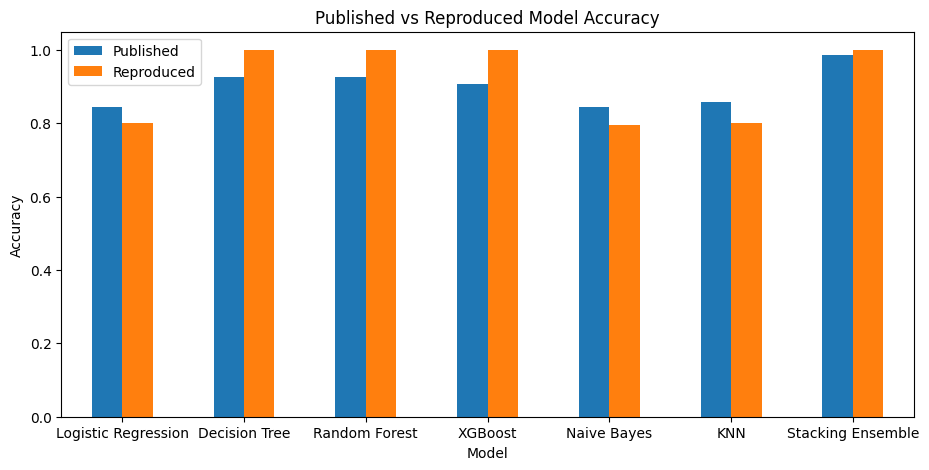

In [31]:
# Plotting the Accuracy of published vs reproduced
comparison_plot = comparison_table[
    ["Model", "Published Accuracy", "Accuracy"]].copy()

comparison_plot = comparison_plot.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Published vs Reproduced Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=0)

plt.legend(["Published", "Reproduced"])
plt.show()

In [32]:
# Checking whether exact observations appear in both training and testing sets
train_rows = X_train.copy()
train_rows["target"] = target_train

test_rows = X_test.copy()
test_rows["target"] = target_test

overlap = test_rows.merge(
    train_rows.drop_duplicates(),
    how="inner"
)

print("Test rows also found in training set:", len(overlap))
print("Percentage of test set overlapping with training:",
      round(len(overlap) / len(test_rows) * 100, 2), "%")

Test rows also found in training set: 196
Percentage of test set overlapping with training: 95.61 %


The reproduced results almost follow the performance pattern shown in the original paper, though several differences were observed.  Logistic Regression, Naive Bayes and KNN produced slightly lower scores than the scores in the paper, while the Decision Tree, Random Forest, XGBoost and the stacking ensemble achieved perfect test-set scores.

However, these results require some careful interpretation, as the dataset contains 723 duplicate rows, and an overlap analysis shows that 196 of the 205 test observations (95.61%) had identical observations present in the training set. This means that the test set is not fully independent of the the training data. This creates a risk that models are recognising previously observed records rather than showeing generalisation to genuinely unseen patients

Therefore, the reproduced scores cannot and should not be interpreted as an evidence of prefect predictive performance, and instead seen as a potential limitation in the original dataset and evaluation protocol. This issue will be investigates in Part 2, where we will redisgn teh experimental procedure to reduce the duplicate-related information overlap and try to provide a more realistic estimate of the model generalisation.

## Part 2
### 2.1 Identified Limitation

The reproduction shows a substantial duplication within the dataset. Of the 1,025 observations, 723 were duplicate rows, which means only 302 were unique records. Furthermore, 95.61% of the observations in the randomly split data set has the identical records present in the training set.

This overlap may result in good performance estimates as the test set is not fully independent of the training data. Hence, the perfect scores obtained by a several classifiers may reflect the recognition of a previously observed data rather than the generalisation to the genuinely unseen observations.

In part 2 we will investigate this limitation by having a more rigorous evaluation framework using only unique observations and leakage-safe validation. The main objective is not necessarily to get a higher accuracy than the reproduced model, but to produce a more reliable estimate of the model performance on an unseen data.

### Research Question:
How will removing the duplicate and overlapping train-test observations, and applying a more rigorous validation framework, affect the estimated generalisation performance of the heart-disease classifiers and stacking ensemble?

### Hypothesis:
Removing the duplicate observations will reduce the high performance observed while reproducing the research paper, but it will provide a more realistic estimate of performance on an actual unseen data.

### 2.2 Experiment 1: Creating the baseline

The reproduced scores in part 1 are used as the baseline. It retains all the 1,025 observations from the original dataset and applies the six classifiers and five-fold stacking ensemble based on the reproduction assumptions. The baseline also identified that 95.61% of test observations had identical records in the training set, which was investigated in Experiment 2

### 2.3 Experiment 2: Removing duplicates and overlapping observation
Here we will remove the duplicates in the dataset, which will leave about 302 unique records, and then we will rerun the same six classifiers and stacking

#### 2.3.1 Removing the Duplicate observation

In [33]:
# Removing the duplicate entries 
heart_data_unique = heart_data.drop_duplicates().reset_index(drop = True)

print("Original observations:", len(heart_data))
print("Unique observations:", len(heart_data_unique))
print("Duplicates Removed:", len(heart_data) - len(heart_data_unique))

print("\n Target Distribution:")
print(heart_data_unique["target"].value_counts())

print("\n Target Percentage:")
print(heart_data_unique["target"].value_counts(normalize=True)
      .mul(100).round(2))


Original observations: 1025
Unique observations: 302
Duplicates Removed: 723

 Target Distribution:
target
1    164
0    138
Name: count, dtype: int64

 Target Percentage:
target
1    54.3
0    45.7
Name: proportion, dtype: float64


In [34]:
# Creating a new split with unique dataset
X_unique = heart_data_unique.drop("target", axis =1)
target_unique = heart_data_unique["target"]

X_unique_train,X_unique_test,target_unique_train,target_unique_test = train_test_split(
    X_unique,
    target_unique,
    test_size=0.20,
    random_state = RANDOM_STATE,
    stratify=target_unique
)

print("Training Observations:", len(X_unique_train))
print("Testing Observations:", len(X_unique_test))

Training Observations: 241
Testing Observations: 61


In [35]:
train_check = X_unique_train.copy()
train_check["target"] = target_unique_train.values

test_check = X_unique_test.copy()
test_check["target"] = target_unique_test.values

overlap_unique = test_check.merge(train_check, how="inner")

print("Test rows also found in training:", len(overlap_unique))
print("Test overlap percentage:",round(len(overlap_unique) / len(test_check) * 100, 2),"%")

Test rows also found in training: 0
Test overlap percentage: 0.0 %


#### 2.3.2 Re-evaluating the Original models

In [36]:
# Scaling the new training data
scaler_unique = StandardScaler()

X_unique_train_scaled = scaler_unique.fit_transform(X_unique_train)
X_unique_test_scaled = scaler_unique.transform(X_unique_test)

In [37]:
# Rerunning the six models
# Logistic Regression
logistic_regression_unique = LogisticRegression(
    max_iter = 1000,
    random_state = RANDOM_STATE
)

logistic_regression_unique.fit(X_unique_train_scaled, target_unique_train)
logistic_regression_unique_result = model_evaluator("Logistic Regression",
                                             logistic_regression_unique,
                                             X_unique_test_scaled,
                                             target_unique_test
                                            )

# Decision Tree
decision_tree_unique = DecisionTreeClassifier(
    random_state = RANDOM_STATE
)

decision_tree_unique.fit(X_unique_train, target_unique_train)
decision_tree_unique_result = model_evaluator("Decision Tree",
                                             decision_tree_unique,
                                             X_unique_test,
                                             target_unique_test
                                            )

# Random Forest
random_forest_unique = RandomForestClassifier(
    random_state = RANDOM_STATE
)

random_forest_unique.fit(X_unique_train, target_unique_train)
random_forest_unique_result = model_evaluator("Random Forest",
                                             random_forest_unique,
                                             X_unique_test,
                                             target_unique_test
                                            )
# XGBoost
extreme_gradient_boost_unique = XGBClassifier(
    random_state = RANDOM_STATE,
    eval_metric="logloss"
)

extreme_gradient_boost_unique.fit(X_unique_train, target_unique_train)
extreme_gradient_boost_unique_result = model_evaluator("XGBoost",
                                                extreme_gradient_boost_unique,
                                                X_unique_test,
                                                target_unique_test)

# Naive Bayes
naive_bayes_unique = GaussianNB()

naive_bayes_unique.fit(X_unique_train_scaled, target_unique_train)
naive_bayes_unique_result = model_evaluator("Naive Bayes",
                                     naive_bayes_unique,
                                     X_unique_test_scaled,
                                     target_unique_test)

# KNN
knn_unique = KNeighborsClassifier()

knn_unique.fit(X_unique_train_scaled, target_unique_train)
knn_unique_result = model_evaluator("KNN",
                             knn_unique,
                             X_unique_test_scaled,
                             target_unique_test)

In [38]:
# combining all the results
unique_dataset_results = pd.DataFrame([
    logistic_regression_unique_result,
    decision_tree_unique_result,
    random_forest_unique_result,
    extreme_gradient_boost_unique_result,
    naive_bayes_unique_result,
    knn_unique_result
])

unique_dataset_results.round(4)

,Model,Accuracy,Precision,Recall,F1,Specificity,MCC,AUC
0,Logistic Regression,0.8525,0.7857,1.0000,0.8800,0.6786,0.7302,0.9448
1,Decision Tree,0.8033,0.8000,0.8485,0.8235,0.7500,0.6031,0.7992
2,Random Forest,0.8689,0.8205,0.9697,0.8889,0.7500,0.7469,0.9264
3,XGBoost,0.8525,0.8000,0.9697,0.8767,0.7143,0.7174,0.9134
4,Naive Bayes,0.8525,0.8000,0.9697,0.8767,0.7143,0.7174,0.9329
5,KNN,0.7869,0.7500,0.9091,0.8219,0.6429,0.5789,0.8615


In [39]:
# Running the same stacking ensemble
stacking_unique = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    cv=stack_cv,
    stack_method="predict_proba"
)

stacking_unique.fit(X_unique_train, target_unique_train)

stacking_unique_result = model_evaluator(
    "Stacking Ensemble",
    stacking_unique,
    X_unique_test,
    target_unique_test
)

stacking_unique_result

{'Model': 'Stacking Ensemble',
 'Accuracy': 0.8524590163934426,
 'Precision': 0.8157894736842105,
 'Recall': 0.9393939393939394,
 'F1': 0.8732394366197183,
 'Specificity': 0.75,
 'MCC': 0.7088392059568465,
 'AUC': 0.9220779220779222}

In [40]:
# Merging both the results
unique_dataset_results = pd.concat([
    unique_dataset_results, 
    pd.DataFrame([stacking_unique_result])
], ignore_index = True)

unique_dataset_results.round(4)

,Model,Accuracy,Precision,Recall,F1,Specificity,MCC,AUC
0,Logistic Regression,0.8525,0.7857,1.0000,0.8800,0.6786,0.7302,0.9448
1,Decision Tree,0.8033,0.8000,0.8485,0.8235,0.7500,0.6031,0.7992
2,Random Forest,0.8689,0.8205,0.9697,0.8889,0.7500,0.7469,0.9264
3,XGBoost,0.8525,0.8000,0.9697,0.8767,0.7143,0.7174,0.9134
4,Naive Bayes,0.8525,0.8000,0.9697,0.8767,0.7143,0.7174,0.9329
5,KNN,0.7869,0.7500,0.9091,0.8219,0.6429,0.5789,0.8615
6,Stacking Ensemble,0.8525,0.8158,0.9394,0.8732,0.7500,0.7088,0.9221


#### 2.3.3 Comparing with Experiment 1

In [41]:
duplicate_comparison = reproduced_results[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
].merge(
    unique_dataset_results[
        ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
    ],
    on="Model",
    suffixes=("_Original", "_Deduplicated"))

duplicate_comparison["Accuracy Change"] = (
    duplicate_comparison["Accuracy_Deduplicated"] - duplicate_comparison["Accuracy_Original"])

duplicate_comparison.round(4)

,Model,Accuracy_Original,Precision_Original,Recall_Original,F1_Original,AUC_Original,Accuracy_Deduplicated,Precision_Deduplicated,Recall_Deduplicated,F1_Deduplicated,AUC_Deduplicated,Accuracy Change
0,Logistic Regression,0.8000,0.7909,0.8286,0.8093,0.8928,0.8525,0.7857,1.0000,0.8800,0.9448,0.0525
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,0.8033,0.8000,0.8485,0.8235,0.7992,-0.1967
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,0.8689,0.8205,0.9697,0.8889,0.9264,-0.1311
3,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,0.8525,0.8000,0.9697,0.8767,0.9134,-0.1475
4,Naive Bayes,0.7951,0.7838,0.8286,0.8056,0.8727,0.8525,0.8000,0.9697,0.8767,0.9329,0.0573
5,KNN,0.8000,0.8265,0.7714,0.7980,0.9230,0.7869,0.7500,0.9091,0.8219,0.8615,-0.0131
6,Stacking Ensemble,1.0000,1.0000,1.0000,1.0000,1.0000,0.8525,0.8158,0.9394,0.8732,0.9221,-0.1475


After removing the 723 duplicate observations, the performance of Decision Tree, Random Forest, XGBoost and the stacking ensemble decreased from the perfect score of 1, as seen in Experiment 1, like, the stacking accuracy decreased from 1.000 to 0.8525, while the Random Forest achieved the highest accuracy of 0.8689, with the new dataset, but Logistic Regression and Naive Bayes slightly improved. 

These result support the hypothesis that duplicate  train-test overlap had inflated some of the original performance estimates, and the evaluation using unique observations provides a more realistic generalisation.

### 2.4 Experiment 3: Proposed Improved Framework

In experiment 2 we removed the duplicate-related train-test overlap, however, evaluating only 302 unique observations using a single 80:20 split with ony 61 test observations makes the results too dependent on chance.

Hence, in experiment 3 we will try to fix this using a repeated stratified cross-validation, leak-free preprocessing, hyperparameter tuning, and out-of-fold stacking. The goal is to make the model evaluation more reliable and trustworthy, rather than just having a higer accuracy score.

#### 2.4.1 Repeated Stratified Cross-Validation

Instead of trusting a 80:20 split, let's evaluate it across 5 folds, each repeated 5 times, so 25 evaluations.

In [42]:
from sklearn.model_selection import RepeatedStratifiedKFold

repeated_cv = RepeatedStratifiedKFold(
    n_splits = 5,
    n_repeats = 5,
    random_state = RANDOM_STATE)

print("Total evaluation folds:",repeated_cv.get_n_splits(X_unique,target_unique))

Total evaluation folds: 25


#### 2.4.2 Hyperparameter tuning

As Random Forest was the best model in experiment 2 at 86.89% accuracy and AUC of 0.9264, we will optimise the RF and XGBoost. These two showed strong performance in the previous experiments and contain several parameters controlling model complexity.

AUC was selected as the optimisation criteria as it evaluates the discrimination across classification thresholds. The search was done using a reasonable parameter ranges, so that we dont risk optimising the small dataset excessively. 

In [43]:
# Random Forest Tuning
from sklearn.model_selection import RandomizedSearchCV

random_forest_para_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 8, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_forest_search = RandomizedSearchCV(
    estimator = RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions = random_forest_para_grid,
    n_iter = 30,
    scoring="roc_auc",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_search.fit(X_unique, target_unique)

print("Best Random Forest parameters:")
print(random_forest_search.best_params_)

print("\n Best Random Forest  CV AUC:")
print(round(random_forest_search.best_score_, 4))
    

Best Random Forest parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 3}

 Best Random Forest  CV AUC:
0.919


In [44]:
# Extreme Gradient Boost Tuning
extreme_gradient_boost_param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

extreme_gradient_boost_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ),
    param_distributions=extreme_gradient_boost_param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

extreme_gradient_boost_search.fit(X_unique, target_unique)

print("Best Extreme Gradient Boostparameters:")
print(extreme_gradient_boost_search.best_params_)

print("\n Best Extreme Gradient Boost CV AUC:")
print(round(extreme_gradient_boost_search.best_score_, 4))
    

Best Extreme Gradient Boostparameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

 Best Extreme Gradient Boost CV AUC:
0.9086


#### 2.4.3 Building an improved stacking ensemble

In [45]:
best_random_forest = random_forest_search.best_estimator_
best_extreme_gradient_boost = extreme_gradient_boost_search.best_estimator_

In [46]:
improved_estimators = [
    ("logestic_regression", Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression( max_iter =1000,
                                      random_state = RANDOM_STATE))
    ])),

    ("decision_tree",DecisionTreeClassifier(
        random_state=RANDOM_STATE)),
    
    ("random_forest", best_random_forest),

    ("extreme_gradient_boosting",best_extreme_gradient_boost),

    ("naive bayes", Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ])),

    ("knn", Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]))
]

improved_stack = StackingClassifier(
    estimators=improved_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)


#### 2.4.4 Evaluating the proposed framework

In [47]:
from sklearn.model_selection import cross_validate

metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "auc": "roc_auc"
}

cv_results = cross_validate(
    improved_stack,
    X_unique,
    target_unique,
    cv = repeated_cv,
    scoring = metrics,
    n_jobs = -1,
    return_train_score = False
)
    

In [48]:
results_table = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1","AUC"],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_auc"].mean()],
    "Standard Deviation": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_auc"].std()]
})

results_table.round(4)

,Metric,Mean,Standard Deviation
0,Accuracy,0.8350,0.0434
1,Precision,0.8264,0.0422
2,Recall,0.8841,0.0611
3,F1,0.8529,0.0395
4,AUC,0.9098,0.0355


#### 2.4.5 Final Nested Evaluation

In [49]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

inner_cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = RANDOM_STATE)

In [50]:
nested_results = []

for fold, (train_index, test_index) in enumerate(
    repeated_cv.split(X_unique, target_unique), start=1):

    # Outer training and teseting
    X_train_outer = X_unique.iloc[train_index]
    X_test_outer = X_unique.iloc[test_index]

    target_train_outer = target_unique.iloc[train_index]
    target_test_outer = target_unique.iloc[test_index]

    # Tuning the Random forest using outer training data
    random_forest_inner_search = RandomizedSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE),
        param_distributions = random_forest_para_grid,
        n_iter = 15,
        scoring="roc_auc",
        cv=inner_cv,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    random_forest_inner_search.fit(X_train_outer, target_train_outer)
    
    # Tuning the Extreme Gradient Boost using outer training data
    extreme_gradient_boost_inner_search = RandomizedSearchCV(
        estimator=XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss"
        ),
        param_distributions=extreme_gradient_boost_param_grid,
        n_iter=15,
        scoring="roc_auc",
        cv=inner_cv,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    extreme_gradient_boost_inner_search.fit(X_train_outer, target_train_outer)

    # Building the stacking ensemble

    nested_estimators = [
        ("logestic_regression", Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression( max_iter =1000,
                                          random_state = RANDOM_STATE))
        ])),
    
        ("decision_tree",DecisionTreeClassifier(
            random_state=RANDOM_STATE)),
        
        ("random_forest", random_forest_inner_search.best_estimator_),
    
        ("extreme_gradient_boosting",extreme_gradient_boost_inner_search.best_estimator_),
    
        ("naive bayes", Pipeline([
            ("scaler", StandardScaler()),
            ("model", GaussianNB())
        ])),
    
        ("knn", Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]))
    ]

    nested_stack = StackingClassifier(
        estimators=nested_estimators,
        final_estimator=LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        cv=5,
        stack_method="predict_proba",
        n_jobs=-1
    )

    # Train only on outer training fold
    nested_stack.fit(X_train_outer, target_train_outer)

    # Testing on unseen outer test fold
    target_pred = nested_stack.predict(X_test_outer)
    target_prob = nested_stack.predict_proba(X_test_outer)[:,1]

    # Saving the results
    nested_results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(target_test_outer, target_pred),
        "Precision": precision_score(target_test_outer, target_pred),
        "Recall": recall_score(target_test_outer, target_pred),
        "F1": f1_score(target_test_outer, target_pred),
        "AUC": roc_auc_score(target_test_outer, target_prob)
    })

print("Completed the nested evaluation")

Completed the nested evaluation


In [51]:
nested_results = pd.DataFrame(nested_results)

nested_results_summary = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1","AUC"],
    "Mean": [
        nested_results["Accuracy"].mean(),
        nested_results["Precision"].mean(),
        nested_results["Recall"].mean(),
        nested_results["F1"].mean(),
        nested_results["AUC"].mean()],
    "Standard Deviation": [
        nested_results["Accuracy"].std(),
        nested_results["Precision"].std(),
        nested_results["Recall"].std(),
        nested_results["F1"].std(),
        nested_results["AUC"].std()]
})

nested_results_summary.round(4)

,Metric,Mean,Standard Deviation
0,Accuracy,0.8284,0.0484
1,Precision,0.8218,0.0444
2,Recall,0.8754,0.0651
3,F1,0.8465,0.0444
4,AUC,0.9064,0.0375


The proposed nested evaluation got a mean accuracy of 0.8284 and AUC of 0.9064 across 25 outer evaluation folds. Although the mean accuracy is lower than the single split results from Experiment 1 and 2, the evaluation is more rigorous as the hyperparameter optimisation occurs only within the training data of each outer fold. 

The relatively small variation across the folds also tell us about the reasonably stable performance. These results suggest that the extremely high performance observed during reproduction was optimistic, and while the proposed framework provides a more realistic estimate of the generalisation to the unseen dataset.

In [52]:
overall_comparsion_table = pd.DataFrame({
    "Experiment": ["Experiment 1 - Reproduction", "Experiment 2 - Deduplicated", "Experiment 3 - Proposed Nested CV"],
    "Evaluation": ["Single 80:20 split","Single 80:20 split","5-fold CV repeated 5 times"],
    "Stacking Accuracy": [1.0000,0.8525,nested_results["Accuracy"].mean()],
    "Stacking F1": [1.0000,0.8732,nested_results["F1"].mean()],
    "Stacking AUC": [1.0000,0.9221,nested_results["AUC"].mean()]
})

overall_comparsion_table.round(4)

,Experiment,Evaluation,Stacking Accuracy,Stacking F1,Stacking AUC
0,Experiment 1 - Reproduction,Single 80:20 split,1.0000,1.0000,1.0000
1,Experiment 2 - Deduplicated,Single 80:20 split,0.8525,0.8732,0.9221
2,Experiment 3 - Proposed Nested CV,5-fold CV repeated 5 times,0.8284,0.8465,0.9064


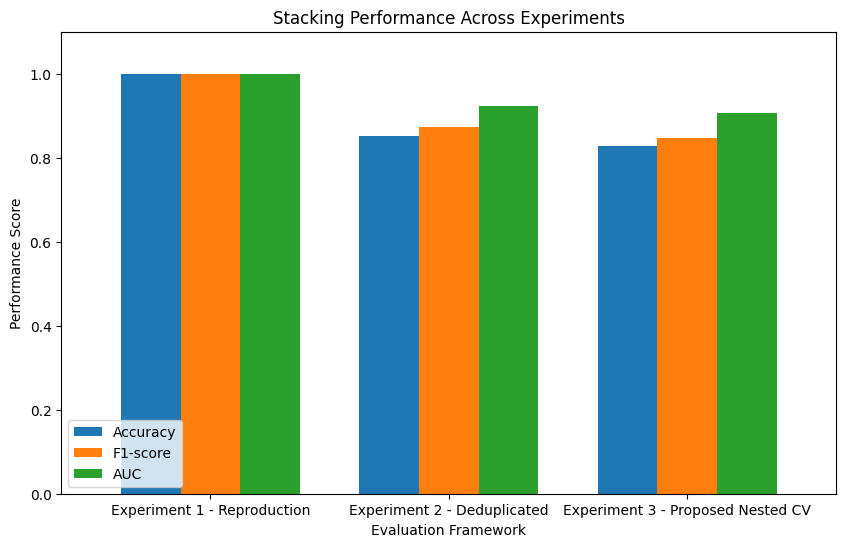

In [53]:
# Visualising the overall comparison of the three experiments
plot_data = overall_comparsion_table.set_index("Experiment")[
    ["Stacking Accuracy", "Stacking F1", "Stacking AUC"]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

ax.set_title("Stacking Performance Across Experiments")
ax.set_xlabel("Evaluation Framework")
ax.set_ylabel("Performance Score")
ax.set_ylim(0, 1.1)

plt.xticks(rotation=0)
plt.legend(
    ["Accuracy", "F1-score", "AUC"],
    loc="lower left"
)
plt.show()

The comparison plot shows the decrease in performance as the evaluation procedure becomes more rigorous. 

Experiment 1 achieved a perfect score but it had substantial duplicate-related train-test overlap. And after removing the duplicates, accuracy decreased to 0.8525, while the nested cross-validation framework produced a mean accuracy of 0.8284 and AUC of 0.9064. 

The lower Experiment 3 scores represent a more reliable estimate of generalisation rather than poor performance

---

Overall, the experiment demonstrates that evaluation methodology can affect the estimated performance of the heart-disease models greatly. The experiment 1 produces a perfect stacking performance, but 95.61% of the train-test overlap raised concerns about the information leakage

Removing the duplicates in Experiment 2 reduced the stacking accuracy to 0.8525. The proposed nested cross-validation framework produced a further estimate of 0.8284 mean accuracy and 0.9064 mean AUC while also maintaining a complete separation between model selection and outer evaluation.

Hence, the proposed approach prioritises a reliable and reproducible generalisation estimates over a high performance from a single potentially optimistic split.

---

## References:

1. M. Bhagat, A. Sharma, and P. Agarwal, “An efficient stacking-based ensemble technique for early heart attack prediction,” Multimedia Tools and Applications, vol. 84, no. 12, pp. 36351–36375, 2025, doi: 10.1007/s11042-024-19293-7.

2. scikit-learn developers (n.d.) StackingClassifier. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html

3. scikit-learn developers (n.d.) RandomizedSearchCV. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html

4. scikit-learn developers (n.d.) RepeatedStratifiedKFold. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html

5. scikit-learn developers (n.d.) StandardScaler. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

6. scikit-learn developers (n.d.) Classification metrics. Available at: https://scikit-learn.org/stable/api/sklearn.metrics.html

7. scikit-learn developers (n.d.) RandomForestClassifier. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

8. scikit-learn developers (n.d.) LogisticRegression. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

9. XGBoost developers (n.d.) XGBoost Python API Reference – XGBClassifier. Available at: https://xgboost.readthedocs.io/en/stable/python/python_api.html

10. Kaggle (n.d.) Heart Disease Dataset. Available at: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset